# Modern Portfolio Theory

Modern Portfolio Theory (Markowitz, 1952) frames investing as a trade-off between expected return and variance. Combining imperfectly correlated assets reduces the variance of the portfolio without proportionally reducing its expected return — this is the mathematical justification for diversification.

For a portfolio with weights $w \in \mathbb{R}^n$, expected return vector $\mu \in \mathbb{R}^n$, and covariance matrix $\Sigma \in \mathbb{R}^{n \times n}$:

- expected return:   $\;\mathbb{E}[R_p] = w^\top \mu$
- variance:          $\;\sigma_p^2 = w^\top \Sigma\, w$
- Sharpe ratio:      $\;S = \dfrac{\mathbb{E}[R_p] - r_f}{\sigma_p}$

The **efficient frontier** is the set of portfolios with the highest expected return for every feasible variance. The **tangency portfolio** is the point on the frontier with the highest Sharpe ratio. `portfolio.models.mpt.portfolio_metrics` wraps `pypfopt.EfficientFrontier` and returns that tangency portfolio.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

from portfolio.config import get_asset_class
from portfolio.data import DataIngestion, compute_returns
from portfolio.models import portfolio_metrics

BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
INK, MUTED, GRID = "#1f2933", "#6b7785", "#e3e6ea"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 130, "savefig.bbox": "tight",
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, RED]),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.grid.axis": "y", "grid.color": GRID, "grid.alpha": 0.5,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.size": 10, "legend.frameon": False,
})

UNIVERSE = ("stocks", "etfs", "crypto")
CLASS_COLORS = {"stocks": BLUE, "etfs": ORANGE, "crypto": RED}
CLASS_LABELS = {name: get_asset_class(name).label for name in UNIVERSE}

preset_class = {
    ticker: name
    for name in UNIVERSE
    for ticker in get_asset_class(name).tickers
}

ingestion = DataIngestion()
prices = ingestion.fetch_prices(list(preset_class))
returns = compute_returns(prices)

asset_class_of = {ticker: preset_class[ticker] for ticker in prices.columns}
classes = pd.Series(asset_class_of, name="asset_class")

classes.value_counts()

asset_class
stocks    52
etfs      33
crypto    12
Name: count, dtype: int64

Before optimising, it helps to see the inputs the optimiser will receive, tagged by the class each asset came from. The annualisation factor of 252 is the conventional number of trading days per year; multiplying daily mean by 252 and daily standard deviation by $\sqrt{252}$ gives the annualised figures `pypfopt` uses internally.

In [2]:
summary = pd.DataFrame({
    "asset_class": classes,
    "annual_return": returns.mean() * 252,
    "annual_volatility": returns.std() * np.sqrt(252),
})
summary["sharpe_naive"] = summary["annual_return"] / summary["annual_volatility"]
summary.sort_values("sharpe_naive", ascending=False).head(10)

,asset_class,annual_return,annual_volatility,sharpe_naive
MU,stocks,1.579442,0.650534,2.427915
CAT,stocks,0.769653,0.339806,2.264976
ZEC-USD,crypto,2.760089,1.401910,1.968805
GOOGL,stocks,0.588617,0.308421,1.908483
INTC,stocks,1.334493,0.707549,1.886079
AMD,stocks,1.114763,0.638485,1.745950
JNJ,stocks,0.316486,0.187157,1.691013
USO,etfs,0.646670,0.419055,1.543163
GLD,etfs,0.400712,0.264159,1.516936
SLV,etfs,0.808605,0.539047,1.500064


### Visualising the risk / return scatter

Each point is one asset, coloured by its class; the optimiser's job is to find a *combination* of these points that lifts the whole portfolio above and to the left of every individual asset.

The classes occupy visibly different regions, which is the whole reason for widening the universe: the bond and Treasury ETFs (`AGG`, `TLT`, `SHY`) hug the left edge, most crypto stretches far to the right, and the two stablecoins in the preset (`USDT-USD`, `USDC-USD`) land almost on the origin — they are dollar pegs, so they behave like cash rather than like the rest of their class.

findfont: Failed to find font weight semibold, now using 700.


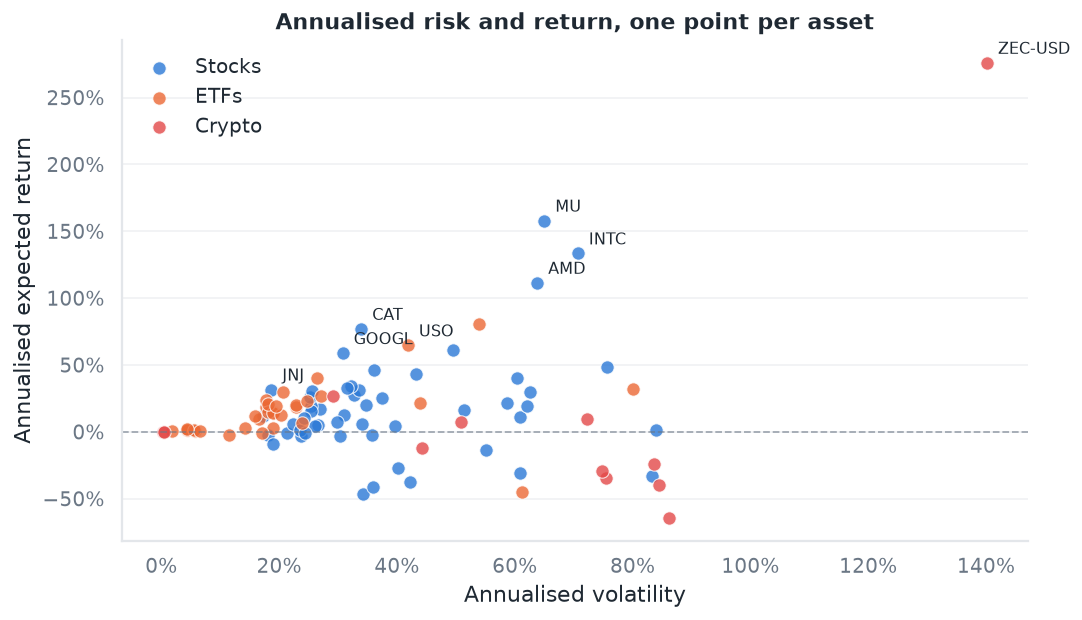

In [3]:
fig, ax = plt.subplots()
for name in UNIVERSE:
    rows = summary[summary["asset_class"] == name]
    ax.scatter(rows["annual_volatility"], rows["annual_return"],
               s=55, alpha=0.8, color=CLASS_COLORS[name],
               edgecolor="white", linewidth=0.6, label=CLASS_LABELS[name])
for ticker, row in summary.sort_values("sharpe_naive", ascending=False).head(8).iterrows():
    ax.annotate(ticker, (row["annual_volatility"], row["annual_return"]),
                xytext=(6, 5), textcoords="offset points", fontsize=9, color=INK)
ax.axhline(0, color=MUTED, linewidth=1, linestyle="--", alpha=0.6)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised expected return")
ax.set_title("Annualised risk and return, one point per asset")
ax.legend(loc="upper left")
plt.show()

## Two-asset warm-up

Before solving the full optimisation, we look at how a simple stocks/bonds split behaves. Variance for a two-asset portfolio is

$$\sigma_p^2 = w_1^2 \sigma_1^2 + w_2^2 \sigma_2^2 + 2 w_1 w_2 \rho_{12} \sigma_1 \sigma_2.$$

Sweeping $w_1$ from 0 to 1 traces a curve in (volatility, expected return) space.

The `bonds` preset holds Treasury *yield* indices (`^IRX`, `^FVX`, `^TNX`, `^TYX`), so a percentage change in one of those columns is a change in a rate, not a return an investor earns. That is fine for this illustration of correlation, which is why bonds appear here and not in the optimised universe above — feeding yields to `mean_historical_return` would produce an expected-return vector with no economic meaning.

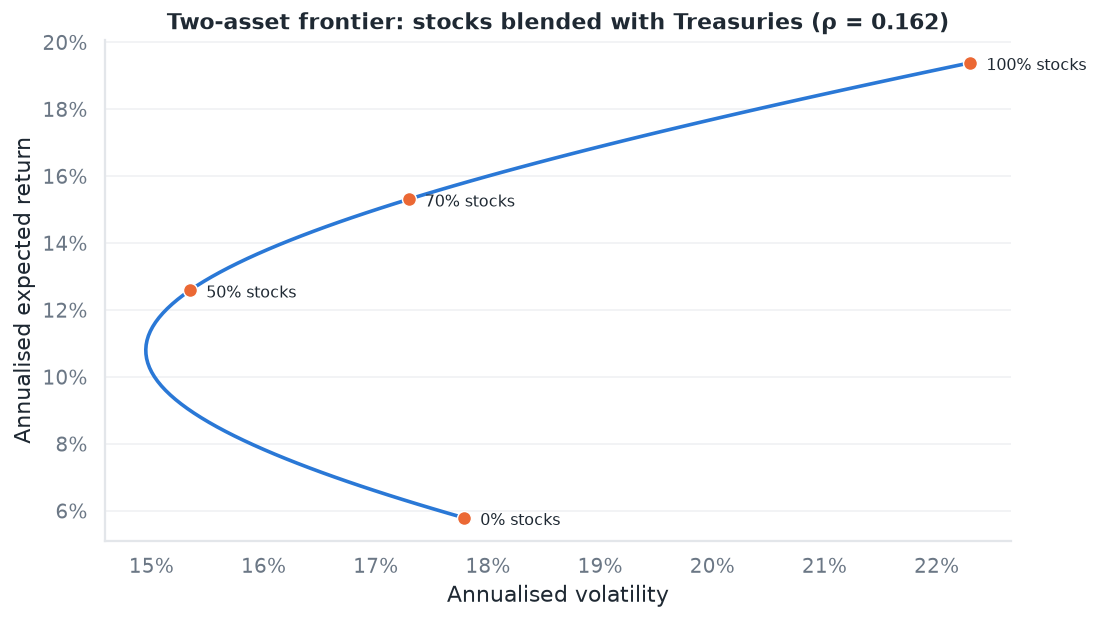

In [4]:
stock_returns = returns[[c for c in returns.columns if asset_class_of[c] == "stocks"]]
bond_returns = compute_returns(ingestion.get_asset_class_prices("bonds"))

mu_stocks = stock_returns.mean().mean() * 252
mu_bonds = bond_returns.mean().mean() * 252
sd_stocks = stock_returns.mean(axis=1).std() * np.sqrt(252)
sd_bonds = bond_returns.mean(axis=1).std() * np.sqrt(252)
rho = stock_returns.mean(axis=1).corr(bond_returns.mean(axis=1))

weights = np.linspace(0, 1, 101)
expected_returns = weights * mu_stocks + (1 - weights) * mu_bonds
variances = (
    (weights ** 2) * sd_stocks ** 2
    + ((1 - weights) ** 2) * sd_bonds ** 2
    + 2 * weights * (1 - weights) * rho * sd_stocks * sd_bonds
)
volatilities = np.sqrt(variances)

fig, ax = plt.subplots()
ax.plot(volatilities, expected_returns, color=BLUE, linewidth=2)
for w in [0.0, 0.5, 0.7, 1.0]:
    idx = int(w * 100)
    ax.scatter(volatilities[idx], expected_returns[idx], color=ORANGE,
               s=60, zorder=3, edgecolor="white", linewidth=0.8)
    ax.annotate(f"{int(w * 100)}% stocks",
                (volatilities[idx], expected_returns[idx]),
                xytext=(9, -4), textcoords="offset points", fontsize=9, color=INK)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised expected return")
ax.set_title(f"Two-asset frontier: stocks blended with Treasuries (ρ = {rho:.3f})")
plt.show()

## Maximizing Sharpe Ratio.

`portfolio_metrics` solves $\arg\max_w S(w)$ subject to $\sum_i w_i = 1$ and $w_i \ge 0$ (long-only, fully invested). The example below runs on the full three-class universe with a 1 % annual risk-free rate, so the optimiser is free to hold equities, ETFs and crypto in whatever mix maximises the Sharpe ratio.

In [5]:
RISK_FREE_RATE = 0.01
metrics = portfolio_metrics(prices, risk_free_rate=RISK_FREE_RATE)

print(f"Expected annual return: {metrics['expected_annual_return']:.4f}")
print(f"Annual volatility:      {metrics['annual_volatility']:.4f}")
print(f"Sharpe ratio:           {metrics['sharpe_ratio']:.4f}")

Expected annual return: 0.9345
Annual volatility:      0.1444
Sharpe ratio:           6.4022


### Visualising the optimal weights

Long-only max-Sharpe portfolios typically concentrate on a handful of historical winners. This is a known weakness of plug-in MPT: the historical mean is a noisy estimator of the future expected return. Production implementations apply shrinkage (Ledoit–Wolf), Black–Litterman views, or explicit weight caps to mitigate this.

Colouring each bar by asset class makes the concentration legible in a way a single-class run cannot: the rollup underneath says whether the optimiser genuinely spread risk across classes, or simply picked the best performers inside one of them.

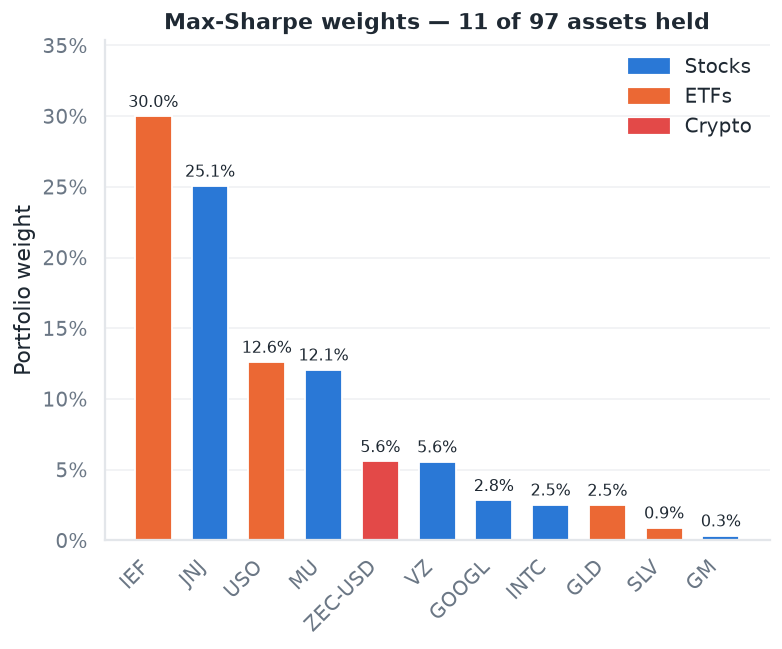

crypto    0.05589
etfs      0.46009
stocks    0.48402
Name: weight, dtype: float64

In [6]:
weights = pd.Series(metrics["weights"]).sort_values(ascending=False)
non_zero = weights[weights > 0]
held_classes = [asset_class_of[ticker] for ticker in non_zero.index]

fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(non_zero)), 5))
ax.bar(non_zero.index, non_zero.to_numpy(), width=0.65,
       color=[CLASS_COLORS[name] for name in held_classes])
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in non_zero],
             padding=3, fontsize=9, color=INK)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, non_zero.max() * 1.18)
ax.set_ylabel("Portfolio weight")
ax.set_title(f"Max-Sharpe weights — {len(non_zero)} of {len(weights)} assets held")
ax.legend(handles=[
    Patch(color=CLASS_COLORS[name], label=CLASS_LABELS[name])
    for name in UNIVERSE if name in set(held_classes)
])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.show()

non_zero.groupby(held_classes).sum().rename("weight")